In [15]:
#pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib

In [16]:
#from google.oauth2.credentials import Credentials

In [17]:
print('hello')
from google.colab import drive
drive.mount('/content/drive')

hello
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold
)
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.io import loadmat
import scipy.io
import json
import copy


%matplotlib inline

---
# **_▞▞ Configuration ▞▞_**

All of the variables that are the most used and prompt to be modified.

To use only one lead, set N_LEADS = 1 and LEAD_INDEX to the specific lead
- 0 = Lead I, 1 = Lead II, 2 = Lead III
- 3–5 = aVR, aVL, aVF
- 6–11 = V1–V6

Set `N_LEADS = 12` and `LEAD_INDEX = None` to use all leads.

---

In [19]:
# lead configuration
N_LEADS     = 12          # Number of input channels: 1 or 12
LEAD_INDEX  = None        # None = all leads; 0-11 = specific lead (only used if N_LEADS=1)
                          # Example for single lead II: N_LEADS=1, LEAD_INDEX=1

# model arch
FILTERS     = 32          # Conv1 filters
KSIZE       = 5           # Kernel size
OUTFEAT     = 5           # number of arrhythmia classes

# training
NUM_FOLDS = 5
EPOCHS      = 20
BATCH_SIZE  = 32
LR          = 1e-3        # https://medium.com/@sahin.samia/how-to-choose-the-right-learning-rate-in-deep-learning-with-pytorch-690de782b405
PATIENCE    = 7           # early stopping patience (epochs without val improvement)
DROPOUT_P   = 0.5         # dropout probability

# data
RANDOMIZER  = 42
TESTSIZE    = 0.15
VALSIZE     = 0.15
SR_RATIO    = 0.5         # keep only 50% of SR samples to reduce class imbalance

# colab related
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
# **_▞▞ Load & Understand the Data ▞▞_**

Columns used:
- rhythm_labels → arrhythmia type to predict
- filename_lr → path to the raw `.dat` ECG file
---

In [20]:
#final well destributed dataset
df_filtered = pd.read_csv('/content/drive/MyDrive/TESIS-V2/Data/model_colab_ready_dataset.csv')

def get_primary_label(labels):
    priority = ['TWC', 'AFIB', 'STACH', 'SBRAD', 'SR']
    for p in priority:
        if p in labels:
            return p
    return labels[0] # failsafe

df_filtered['primary_label'] = df_filtered['filtered_labels'].apply(get_primary_label)

# undersampling
# find the size of our smallest class (TWC in this case)
min_class_size = df_filtered['primary_label'].value_counts().min()
print(f"Balancing all classes to match the smallest class size: {min_class_size} records")

# group by the primary label, and randomly sample exactly 'min_class_size' rows from each
df_balanced = df_filtered.groupby('primary_label').sample(n=min_class_size, random_state=RANDOMIZER).reset_index(drop=True)

# 7. Verification
print("\n--- FINAL BALANCED COUNTS ---")
print(df_balanced['primary_label'].value_counts())
print(f"\nFinal dataset ready for training: {len(df_balanced)} records")

Balancing all classes to match the smallest class size: 6269 records

--- FINAL BALANCED COUNTS ---
primary_label
AFIB     6269
SBRAD    6269
SR       6269
STACH    6269
TWC      6269
Name: count, dtype: int64

Final dataset ready for training: 31345 records


In [21]:
df_balanced.describe()

,strat_fold,age,sex
count,31345.000000,31315.000000,31336.000000
mean,5.488371,62.286476,0.443005
std,2.868391,22.353387,0.496749
min,1.000000,0.000000,0.000000
25%,3.000000,52.000000,0.000000
50%,5.000000,64.000000,0.000000
75%,8.000000,75.000000,1.000000
max,10.000000,300.000000,1.000000


---
# **_▞▞ Dataset Class ▞▞_**

- **Class weight computation**: Returns weights to pass into `CrossEntropyLoss` to handle class imbalance.
---

In [22]:
arrhythmia_map = {
    'SR': 0, 'AFIB': 1, 'STACH': 2,'SBRAD': 3, 'TWC': 4, 
}

# Human-readable names for plots
CLASS_NAMES = [
    'SR', 'AFIB', 'STACH', 'SBRAD', 'TWC'
]


class PTBXLDataset(Dataset):
    def __init__(
        self,
        csv_file,
        max_samples=None,
        #downsample_sr=False,
        #sr_ratio=1.0,
        random_state=RANDOMIZER,
        lead_index=None      # None = all 12 leads; 0-11 = single lead
    ):

        self.lead_index = lead_index
        self.df         = pd.read_csv(csv_file)

        # ── Label extraction ─────────────────────────────────────────
        self.df["target"] = self.df["primary_label"].map(arrhythmia_map)
        self.df = self.df.dropna(subset=["target"]).copy()
        self.df["target"] = self.df["target"].astype(np.int64)

        if max_samples is not None:
            self.df = self.df.sample(max_samples, random_state=random_state).copy()

        # ── Downsample dominant SR class ─────────────────────────────
        """
        if downsample_sr:
            sr_df    = self.df[self.df["target"] == 0].copy()
            non_sr   = self.df[self.df["target"] != 0].copy()
            sr_keep  = min(int(len(non_sr) * sr_ratio), len(sr_df))
            sr_df    = sr_df.sample(n=sr_keep, random_state=random_state)
            self.df  = pd.concat([sr_df, non_sr], axis=0)
            self.df  = self.df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        """
        self.df = self.df.reset_index(drop=True)

        print(f"Total records loaded: {len(self.df)}")
        print("\nClass distribution:")
        dist = self.df["target"].value_counts().sort_index()
        for idx, count in dist.items():
            print(f"  {idx:2d} ({CLASS_NAMES[idx]:6s}): {count}")

    def get_class_weights(self):
        """Compute inverse-frequency weights for CrossEntropyLoss.
        https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html"""
        labels          = self.df["target"].values
        present_classes = np.unique(labels)  # only classes that actually exist

        weights_partial = compute_class_weight(
            class_weight="balanced",
            classes=present_classes,
            y=labels
        )

        # Build a full 12-class weight tensor, defaulting missing classes to 1.0
        weights_full = np.ones(OUTFEAT, dtype=np.float32)
        for cls, w in zip(present_classes, weights_partial):
            weights_full[cls] = w

        return torch.tensor(weights_full, dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        base_path = row["file_path"]

        dat_path = base_path + ".dat"
        mat_path = base_path + ".mat"

        # -------------------------------------------------
        # try .dat first
        # -------------------------------------------------
        if os.path.exists(dat_path):
            with open(dat_path, "rb") as f:
                raw = np.fromfile(f, dtype=np.int16)

            n_samples = len(raw) // 12
            data = raw[: n_samples * 12].reshape(n_samples, 12)

            # convert to (12, 1000)
            if n_samples >= 1000:
                data = data[:1000, :]
            else:
                pad = np.zeros((1000 - n_samples, 12), dtype=np.int16)
                data = np.vstack([data, pad])

            x = torch.tensor(data, dtype=torch.float32).T / 1000.0  # (12, 1000)

        # -------------------------------------------------
        # if .dat does not exist, try .mat
        # -------------------------------------------------
        elif os.path.exists(mat_path):
            mat_data = loadmat(mat_path)

            # Most ECG .mat files use the key "val"
            if "val" not in mat_data:
                raise KeyError(f"No 'val' variable found inside: {mat_path}")

            data = mat_data["val"].astype(np.float32)

            # expected shape: (12, N)
            # if shape comes reversed, fix it
            if data.shape[0] != 12 and data.shape[1] == 12:
                data = data.T

            if data.shape[0] != 12:
                raise ValueError(f"Unexpected .mat shape {data.shape} in file: {mat_path}")

            n_samples = data.shape[1]

            # normalize to 1000 samples
            if n_samples >= 1000:
                data = data[:, :1000]
            else:
                pad = np.zeros((12, 1000 - n_samples), dtype=np.float32)
                data = np.hstack([data, pad])

            x = torch.tensor(data, dtype=torch.float32) / 1000.0  # (12, 1000)

        # -------------------------------------------------
        # if neither exists, fail 
        # -------------------------------------------------
        else:
            raise FileNotFoundError(
                f"Neither .dat nor .mat file was found for base path: {base_path}"
            )

        #SINGLE LEAD OPTION
        if self.lead_index is not None:
            x = x[self.lead_index].unsqueeze(0)          # (1, 1000)

        y = torch.tensor(int(row["target"]), dtype=torch.long)
        return x, y

---
# **_▞▞ Model Architecture ▞▞_**


- **BatchNorm1d** added after each conv layer — normalizes activations, stabilizes training, and acts as additional regularization alongside dropout.
- **Adaptive pooling**  — removes the hard-coded `15808` flat size, so the model works whether you use 12 leads or 1. it slides a window over the time axis and keeps the strongest activation, which compresses the sequence and makes the model focus on the most prominent features (like QRS peaks) rather than every sample.
- **Deeper architecture** — 3 conv blocks instead of 2, so the model can learn more complex patterns without memorizing.
- **Dropout** — helps with overfitting by preventing the model from depending too much on specific features

---

In [23]:
class ECGModel(nn.Module):
    def __init__(self, n_leads=12, n_classes=12, dropout_p=0.5):
        super().__init__()

        # Each block: Conv1d → BatchNorm → ReLU → MaxPool
        self.conv1 = nn.Conv1d(n_leads, 32,  kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32,      64,  kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64,      128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        self.pool    = nn.MaxPool1d(2)

        # AdaptiveAvgPool1d(4) → always outputs 128*4=512 features
        # regardless of input length or number of leads.
        # This removes the fragile hard-coded flat size.
        self.global_pool = nn.AdaptiveAvgPool1d(4)

        # ── Fully connected ───────────────────────────────────────────
        self.dropout = nn.Dropout(dropout_p) #https://www.geeksforgeeks.org/deep-learning/dropout-regularization-in-deep-learning/ 
        self.fc1     = nn.Linear(128 * 4, 256)
        self.fc2     = nn.Linear(256, 128)
        self.out     = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.out(x)

In [24]:
def plot_ecg_with_heatmap(signal, heatmap, title="", figsize=(14, 4)):
    """
    signal: 1D numpy array of ECG samples
    heatmap: 1D numpy array same length as signal, values in [0,1]
    """
    signal = np.asarray(signal)
    heatmap = np.asarray(heatmap)

    x = np.arange(len(signal))

    plt.figure(figsize=figsize)
    plt.plot(x, signal, color='black', linewidth=1.0, label='ECG')

    # color overlay using scatter
    plt.scatter(x, signal, c=heatmap, cmap='jet', s=8, alpha=0.8, label='Importance')

    plt.colorbar(label='XAI importance')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Time step")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

---
# **_▞▞ Load Data & Initialize Model ▞▞_**

Key changes:
- **Weighted CrossEntropyLoss** — penalizes errors on rare classes more, combating class imbalance.
- **Lower learning rate** (`1e-3`) — reduces risk of overshooting good minima.
- **ReduceLROnPlateau scheduler** — automatically halves the LR when val_loss stops improving.
---

In [25]:
csv_path = '/content/drive/MyDrive/TESIS-V2/Data/model_colab_ready_dataset.csv'

dataset = PTBXLDataset(
    csv_file=csv_path,
    max_samples=10000,
    lead_index=LEAD_INDEX
)

# ============================================================
# Holdout test split + cross-validation on the remaining data
# ============================================================
NUM_FOLDS = 5
NUM_WORKERS = 2
PIN_MEMORY = True

# Auto-detect an optional grouping column to reduce leakage
candidate_group_cols = ['patient_id', 'patient', 'subject_id', 'study_id', 'record_id']
GROUP_COL = next((c for c in candidate_group_cols if c in dataset.df.columns), None)
groups_all = dataset.df[GROUP_COL].values if GROUP_COL is not None else None

labels_all = dataset.df['target'].values
all_indices = np.arange(len(dataset))

# Keep an untouched holdout test set for final evaluation
if GROUP_COL is not None:
    unique_groups = dataset.df[GROUP_COL].dropna().unique()
    train_groups, test_groups = train_test_split(
        unique_groups,
        test_size=TESTSIZE,
        random_state=RANDOMIZER
    )

    trainval_mask = dataset.df[GROUP_COL].isin(train_groups).values
    test_mask     = dataset.df[GROUP_COL].isin(test_groups).values

    trainval_indices = all_indices[trainval_mask]
    test_indices     = all_indices[test_mask]
else:
    trainval_indices, test_indices = train_test_split(
        all_indices,
        test_size=TESTSIZE,
        random_state=RANDOMIZER,
        stratify=labels_all
    )

print(f'Total dataset: {len(dataset)}')
print(f'Train/Val pool for CV: {len(trainval_indices)}')
print(f'Holdout test set: {len(test_indices)}')
if GROUP_COL is not None:
    print(f'Grouped split enabled with column: {GROUP_COL}')
else:
    print('No patient/group column detected. Using stratified sample-level CV.')

# Prepare CV splitter on train/val pool only
trainval_labels = labels_all[trainval_indices]

def make_cv_splits(indices, labels, groups=None, n_splits=5, random_state=42):
    if groups is None:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        return list(skf.split(np.zeros(len(indices)), labels))

    # GroupKFold preserves groups but is not stratified; we still use it if groups exist
    gkf = GroupKFold(n_splits=n_splits)
    return list(gkf.split(np.zeros(len(indices)), labels, groups))

cv_groups = groups_all[trainval_indices] if GROUP_COL is not None else None
cv_splits = make_cv_splits(
    trainval_indices,
    trainval_labels,
    groups=cv_groups,
    n_splits=NUM_FOLDS,
    random_state=RANDOMIZER
)

test_dataset = Subset(dataset, test_indices)
test_loader  = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print(f'Prepared {len(cv_splits)} CV folds.')


Total records loaded: 10000

Class distribution:
   0 (SR    ): 2002
   1 (AFIB  ): 2006
   2 (STACH ): 1839
   3 (SBRAD ): 2083
   4 (TWC   ): 2070
Total dataset: 10000
Train/Val pool for CV: 8500
Holdout test set: 1500
No patient/group column detected. Using stratified sample-level CV.
Prepared 5 CV folds.


---
# **_▞▞ Training Loop with Early Stopping ▞▞_**

- **Early stopping** — saves the best model weights and stops training when val_loss hasn't improved for `PATIENCE` epochs.
- **LR scheduler** — steps after each epoch based on val_loss.
---

In [26]:
def build_class_weights_from_indices(dataset_obj, subset_indices, n_classes, device):
    fold_labels = dataset_obj.df.iloc[subset_indices]['target'].values
    present_classes = np.unique(fold_labels)

    weights_partial = compute_class_weight(
        class_weight='balanced',
        classes=present_classes,
        y=fold_labels
    )

    weights_full = np.ones(n_classes, dtype=np.float32)
    for cls, weight in zip(present_classes, weights_partial):
        weights_full[cls] = weight

    return torch.tensor(weights_full, dtype=torch.float32).to(device)


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds, labels = [], []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            running_loss += loss.item()
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(batch_y.cpu().numpy())

    avg_loss = running_loss / max(len(data_loader), 1)
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(labels, preds),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'preds': preds,
        'labels': labels
    }
    return metrics


fold_results = []
fold_histories = []
best_overall = {
    'fold': None,
    'val_loss': float('inf'),
    'state_dict': None
}


In [27]:
history = {
    'loss': [], 'accuracy': [], 'f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_f1': []
}

best_val_loss   = float('inf')
patience_counter = 0
best_model_path  = 'best_ecg_model.pt'


In [28]:
for fold, (inner_train_pos, inner_val_pos) in enumerate(cv_splits, start=1):
    print('\n' + '=' * 70)
    print(f'Fold {fold}/{NUM_FOLDS}')
    print('=' * 70)

    train_idx = trainval_indices[inner_train_pos]
    val_idx   = trainval_indices[inner_val_pos]

    train_dataset = Subset(dataset, train_idx)
    val_dataset   = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    model = ECGModel(n_leads=N_LEADS, n_classes=OUTFEAT, dropout_p=DROPOUT_P).to(device)

    class_weights = build_class_weights_from_indices(
        dataset_obj=dataset,
        subset_indices=train_idx,
        n_classes=OUTFEAT,
        device=device
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = {
        'loss': [], 'accuracy': [], 'f1_weighted': [], 'f1_macro': [],
        'val_loss': [], 'val_accuracy': [], 'val_f1_weighted': [], 'val_f1_macro': [],
        'lr': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_fold_path = f'best_ecg_model_fold_{fold}.pt'

    for epoch in range(EPOCHS):
        # ---------------- TRAIN ----------------
        model.train()
        train_loss, train_preds, train_labels = 0.0, [], []

        for batch_X, batch_y in tqdm(
            train_loader,
            desc=f'Fold {fold} | Epoch {epoch+1}/{EPOCHS}',
            unit='batch'
        ):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            train_labels.extend(batch_y.cpu().numpy())

        avg_train_loss = train_loss / max(len(train_loader), 1)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1_weighted = f1_score(train_labels, train_preds, average='weighted', zero_division=0)
        train_f1_macro    = f1_score(train_labels, train_preds, average='macro', zero_division=0)

        # ---------------- VALIDATE ----------------
        val_metrics = evaluate_model(model, val_loader, criterion, device)
        avg_val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_f1_weighted = val_metrics['f1_weighted']
        val_f1_macro    = val_metrics['f1_macro']

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['loss'].append(avg_train_loss)
        history['accuracy'].append(train_acc)
        history['f1_weighted'].append(train_f1_weighted)
        history['f1_macro'].append(train_f1_macro)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_acc)
        history['val_f1_weighted'].append(val_f1_weighted)
        history['val_f1_macro'].append(val_f1_macro)
        history['lr'].append(current_lr)

        print(
            f'Fold {fold} | Epoch [{epoch+1}/{EPOCHS}] | '
            f'loss: {avg_train_loss:.4f} | acc: {train_acc:.4f} | '
            f'f1_w: {train_f1_weighted:.4f} | f1_m: {train_f1_macro:.4f} || '
            f'val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.4f} | '
            f'val_f1_w: {val_f1_weighted:.4f} | val_f1_m: {val_f1_macro:.4f} | '
            f'lr: {current_lr:.6f}'
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_fold_path)
            print(f'  ✓ Best fold model saved (val_loss={best_val_loss:.4f})')
        else:
            patience_counter += 1
            print(f'  ✗ No improvement ({patience_counter}/{PATIENCE})')
            if patience_counter >= PATIENCE:
                print(f'\nEarly stopping in fold {fold} at epoch {epoch+1}.')
                break

    model.load_state_dict(torch.load(best_fold_path, weights_only=True))
    final_val_metrics = evaluate_model(model, val_loader, criterion, device)

    fold_results.append({
        'fold': fold,
        'best_val_loss': best_val_loss,
        'val_accuracy': final_val_metrics['accuracy'],
        'val_f1_weighted': final_val_metrics['f1_weighted'],
        'val_f1_macro': final_val_metrics['f1_macro'],
        'model_path': best_fold_path
    })
    fold_histories.append(history)

    if best_val_loss < best_overall['val_loss']:
        best_overall['fold'] = fold
        best_overall['val_loss'] = best_val_loss
        best_overall['state_dict'] = copy.deepcopy(model.state_dict())

print('\nCross-validation complete.')

cv_summary = pd.DataFrame(fold_results)
display(cv_summary)

print('\n===== Cross-validation summary =====')
print(f"Best fold        : {best_overall['fold']}")
print(f"Mean val loss    : {cv_summary['best_val_loss'].mean():.4f} ± {cv_summary['best_val_loss'].std():.4f}")
print(f"Mean val acc     : {cv_summary['val_accuracy'].mean():.4f} ± {cv_summary['val_accuracy'].std():.4f}")
print(f"Mean val F1 w    : {cv_summary['val_f1_weighted'].mean():.4f} ± {cv_summary['val_f1_weighted'].std():.4f}")
print(f"Mean val F1 macro: {cv_summary['val_f1_macro'].mean():.4f} ± {cv_summary['val_f1_macro'].std():.4f}")

# Load the best fold model for final test evaluation
model = ECGModel(n_leads=N_LEADS, n_classes=OUTFEAT, dropout_p=DROPOUT_P).to(device)
model.load_state_dict(best_overall['state_dict'])

# Keep a single history object for plotting compatibility
history = fold_histories[best_overall['fold'] - 1]



Fold 1/5


Fold 1 | Epoch 1/20:   0%|          | 0/213 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Fold 1 | Epoch 1/20: 100%|██████████| 213/213 [19:41<00:00,  5.54s/batch]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fold 1 | Epoch [1/20] | loss: 1.4042 | acc: 0.3906 | f1_w: 0.3854 | f1_m: 0.3835 || val_loss: 1.1768 | val_acc: 0.5294 | val_f1_w: 0.5207 | val_f1_m: 0.5201 | lr: 0.001000
  ✓ Best fold model saved (val_loss=1.1768)


Fold 1 | Epoch 2/20:   0%|          | 0/213 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Fold 1 | Epoch 2/20: 100%|██████████| 213/213 [00:47<00:00,  4.53batch/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fold 1 | Epoch [2/20] | loss: 1.2052 | acc: 0.5253 | f1_w: 0.5138 | f1_m: 0.5130 || val_loss: 1.0379 | val_acc: 0.5641 | val_f1_w: 0.5229 | val_f1_m: 0.5224 | lr: 0.001000
  ✓ Best fold model saved (val_loss=1.0379)


...

Fold 5 | Epoch [20/20] | loss: 0.7260 | acc: 0.7194 | f1_w: 0.7175 | f1_m: 0.7184 || val_loss: 0.7152 | val_acc: 0.7229 | val_f1_w: 0.7216 | val_f1_m: 0.7220 | lr: 0.001000
  ✓ Best fold model saved (val_loss=0.7152)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Cross-validation complete.


,fold,best_val_loss,val_accuracy,val_f1_weighted,val_f1_macro,model_path
0,1,0.722094,0.712353,0.714136,0.714562,best_ecg_model_fold_1.pt
1,2,0.729914,0.713529,0.712377,0.713570,best_ecg_model_fold_2.pt
2,3,0.732886,0.715294,0.717459,0.717867,best_ecg_model_fold_3.pt
3,4,0.733734,0.705294,0.703097,0.704518,best_ecg_model_fold_4.pt
4,5,0.715223,0.722941,0.721563,0.722014,best_ecg_model_fold_5.pt



===== Cross-validation summary =====
Best fold        : 5
Mean val loss    : 0.7268 ± 0.0079
Mean val acc     : 0.7139 ± 0.0063
Mean val F1 w    : 0.7137 ± 0.0069
Mean val F1 macro: 0.7145 ± 0.0065


---
# **_▞▞ Training Curves ▞▞_**
---

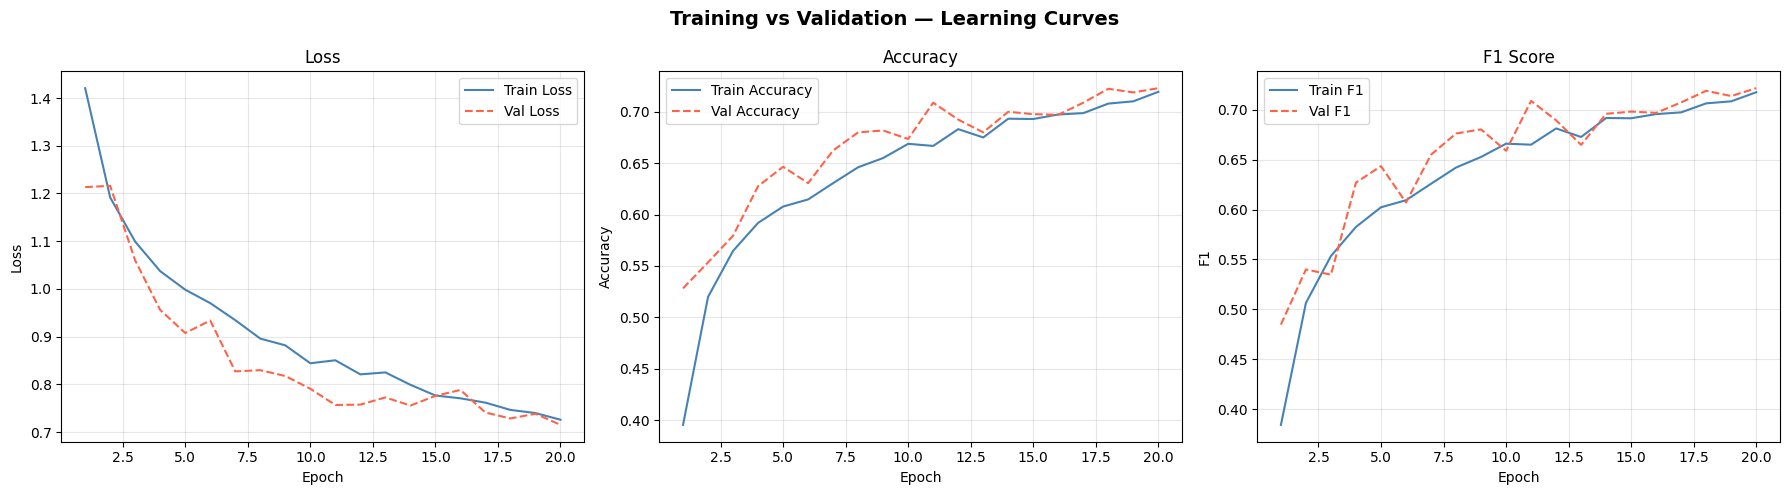

Saved: training_curves.png


In [32]:
epochs_ran = len(history['loss'])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(x_axis, history['loss'],     label='Train Loss',    color='steelblue')
axes[0].plot(x_axis, history['val_loss'], label='Val Loss',      color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(x_axis, history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(x_axis, history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(x_axis, history['f1_weighted'],     label='Train F1', color='steelblue')
axes[2].plot(x_axis, history['val_f1_weighted'], label='Val F1',   color='tomato', linestyle='--')
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

---
# **_▞▞ Evaluation on Test Set ▞▞_**
---

In [33]:
model.eval()
test_preds, test_labels = [], []

# fold-specific test criterion is not strictly necessary for predictions,
# but we keep metric computation explicit.
test_class_weights = build_class_weights_from_indices(
    dataset_obj=dataset,
    subset_indices=trainval_indices,
    n_classes=OUTFEAT,
    device=device
)
test_criterion = nn.CrossEntropyLoss(weight=test_class_weights)

test_metrics = evaluate_model(model, test_loader, test_criterion, device)
test_preds = test_metrics['preds']
test_labels = test_metrics['labels']

test_acc   = test_metrics['accuracy']
test_f1    = test_metrics['f1_weighted']
test_f1_m  = test_metrics['f1_macro']
test_prec  = precision_score(test_labels, test_preds, average='weighted', zero_division=0)
test_rec   = recall_score(test_labels, test_preds, average='weighted', zero_division=0)

print('='*55)
print('  HOLDOUT TEST SET RESULTS')
print('='*55)
print(f'  Accuracy   : {test_acc:.4f}')
print(f'  F1 Weighted: {test_f1:.4f}')
print(f'  F1 Macro   : {test_f1_m:.4f}')
print(f'  Precision  : {test_prec:.4f}')
print(f'  Recall     : {test_rec:.4f}')
print('='*55)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  HOLDOUT TEST SET RESULTS
  Accuracy   : 0.7020
  F1 Weighted: 0.7009
  F1 Macro   : 0.7021
  Precision  : 0.7069
  Recall     : 0.7020


---
# **_▞▞ Classification Report ▞▞_**

Shows per-class precision, recall and F1. This is the best way to see which arrhythmia types the model struggles with (often the rare classes like PSVT or BIGU).

---

In [34]:
# Only include classes that actually appear in the test set
present_classes = sorted(set(test_labels))
present_names   = [CLASS_NAMES[i] for i in present_classes]

print(classification_report(
    test_labels, test_preds,
    labels=present_classes,
    target_names=present_names,
    zero_division=0
))

              precision    recall  f1-score   support

          SR       0.88      0.72      0.79       300
        AFIB       0.63      0.55      0.59       301
       STACH       0.69      0.84      0.76       276
       SBRAD       0.76      0.81      0.78       312
         TWC       0.58      0.60      0.59       311

    accuracy                           0.70      1500
   macro avg       0.71      0.70      0.70      1500
weighted avg       0.71      0.70      0.70      1500



---
# **_▞▞ Confusion Matrix ▞▞_**

Each row = the true class. Each column = what the model predicted.
A perfect model would have all values on the diagonal.
Off-diagonal values tell you which classes are being confused with each other.

---

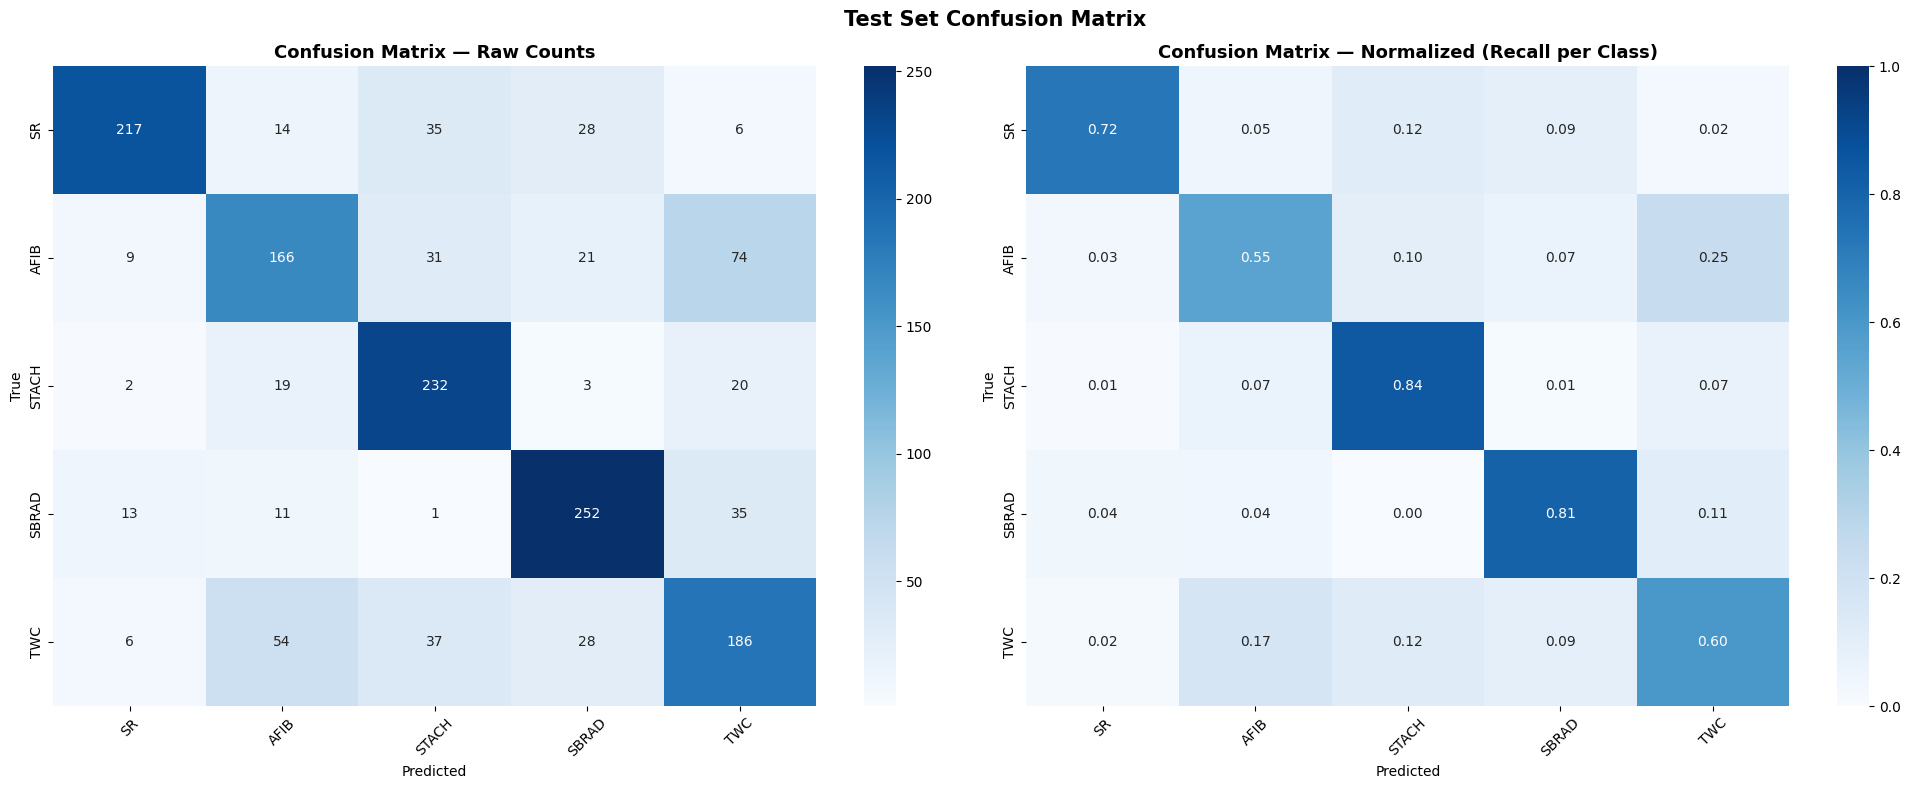

Saved: confusion_matrix.png


In [35]:
cm = confusion_matrix(test_labels, test_preds, labels=present_classes)

# Normalize by row (true labels) so each row sums to 1
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── raw counts ───────────────────────────────────────────
sns.heatmap(
    cm, ax=axes[0],
    annot=True, fmt='d', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names
)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# ── recall per class ─────────────────────────────────────
sns.heatmap(
    cm_normalized, ax=axes[1],
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalized (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Test Set Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

---
# **_▞▞ Per-Class F1 Bar Chart ▞▞_**

A quick visual to identify which arrhythmia types are hardest to classify.

---

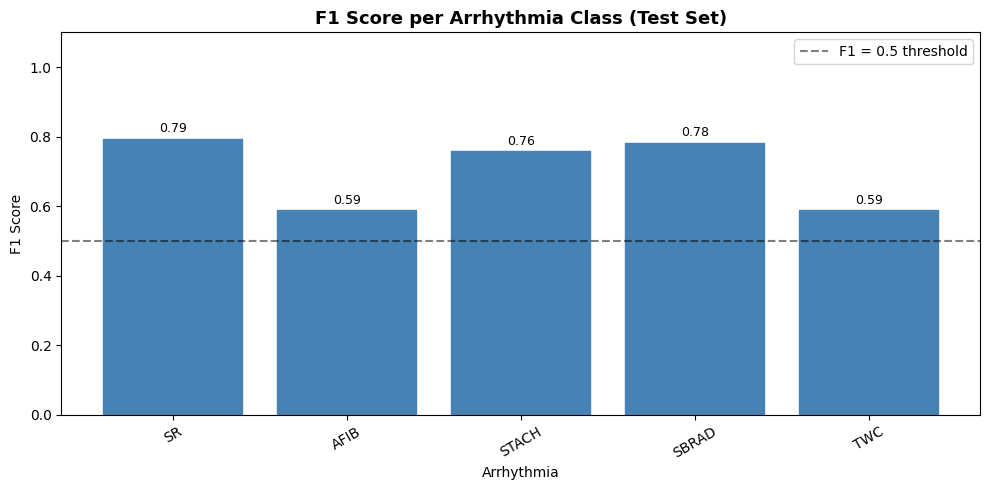

Saved: f1_per_class.png


In [36]:
f1_per_class = f1_score(test_labels, test_preds, labels=present_classes, average=None, zero_division=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(present_names, f1_per_class, color='steelblue', edgecolor='white')

# Color bars below 0.5 in red to highlight problem classes
for bar, score in zip(bars, f1_per_class):
    bar.set_color('tomato' if score < 0.5 else 'steelblue')
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=9)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='F1 = 0.5 threshold')
plt.title('F1 Score per Arrhythmia Class (Test Set)', fontsize=13, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f1_per_class.png")

---
# **_▞▞ Class Distribution Plot ▞▞_**

Visualize how balanced (or imbalanced) the dataset is after downsampling SR.

---

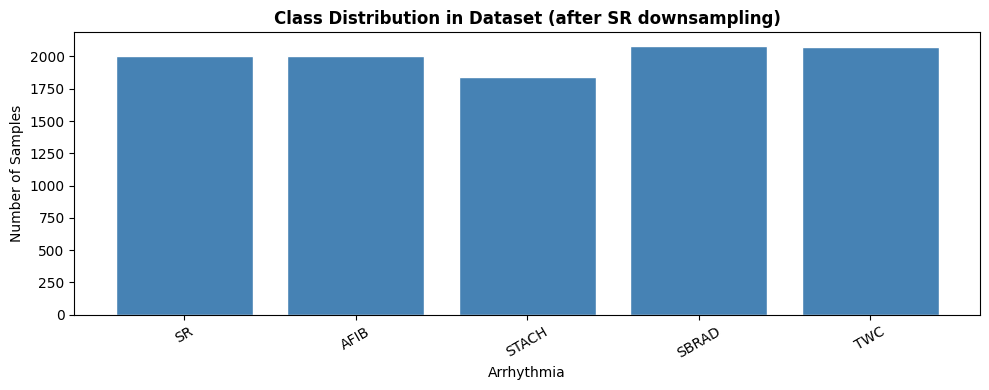

In [37]:
dist = dataset.df['target'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in dist.index], dist.values, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Dataset (after SR downsampling)', fontsize=12, fontweight='bold')
plt.xlabel('Arrhythmia')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# **_▞▞ Save Model ▞▞_**
---

In [38]:
save_path = '/content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_best_fold.pt'
torch.save(model.state_dict(), save_path)
print(f'Best CV model saved to: {save_path}')


Best CV model saved to: /content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_best_fold.pt


In [39]:
history_path = '/content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_best_fold_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f)

cv_results_path = '/content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_results.json'
with open(cv_results_path, 'w') as f:
    json.dump(fold_results, f, indent=2)

print(f'Best-fold history saved to: {history_path}')
print(f'Fold results saved to: {cv_results_path}')


Best-fold history saved to: /content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_best_fold_history.json
Fold results saved to: /content/drive/MyDrive/TESIS-V2/crossval_ecg_arrhythmia_model_cv_results.json


---
# **_▞▞ Load Model ▞▞_**
---

In [ ]:
#load
#model = ECGModel()
#model.load_state_dict(torch.load('/content/drive/MyDrive/TESIS-V2/3rd_ecg_arrhythmia_model_v2.pt', weights_only=True))
#model.eval()


ECGModel(
  (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=4)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=12, bias=True)
)

In [ ]:
#history_path = '/content/drive/MyDrive/TESIS-V2/3rd_ecg_arrhythmia_model_v2_history.json'
#with open(history_path, 'r') as f:
#    history = json.load(f)


#print(f"History loaded — {len(history['loss'])} epochs of data found.")

History loaded — 10 epochs of data found.


---
# **_▞▞ Single File Inference ▞▞_**

Run inference on a single `.dat` file. Set `inference_lead` to a number (0–11) to use only that lead, or `None` to use all 12.

---

In [40]:
inference_lead    = LEAD_INDEX
single_file_path  = '/content/drive/MyDrive/TESIS-V2/Data/Chapman/WFDBRecords/37/378/JS37219.mat'

# ── Load file based on extension ─────────────────────────────────────
ext = os.path.splitext(single_file_path)[-1].lower()

if ext == '.dat':
    with open(single_file_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np.int16)
    n_samples = len(raw_data) // 12
    raw_data  = raw_data[:n_samples * 12].reshape(n_samples, 12).astype(np.float32) / 1000.0

elif ext == '.mat':
    mat = scipy.io.loadmat(single_file_path)

    # .mat files from different datasets use different key names —
    # this tries the most common ones automatically
    possible_keys = ['val', 'data', 'signal', 'ECG', 'ecg']
    raw_data      = None
    for key in possible_keys:
        if key in mat:
            raw_data = mat[key].astype(np.float32)
            break

    if raw_data is None:
        # Show available keys so you can identify the right one
        available = [k for k in mat.keys() if not k.startswith('_')]
        raise KeyError(f"Could not find ECG data in .mat file. Available keys: {available}")

    # .mat files are usually shaped (12, N) already — normalize if needed
    if raw_data.shape[0] == 12:
        raw_data = raw_data.T          # → (N, 12)
    elif raw_data.shape[1] != 12:
        raise ValueError(f"Unexpected .mat shape: {raw_data.shape}. Expected (12, N) or (N, 12).")

    # Normalize amplitude if values look like raw ADC counts (not millivolts)
    if np.abs(raw_data).max() > 10:
        raw_data = raw_data / 1000.0

else:
    raise ValueError(f"Unsupported file format: '{ext}'. Expected .dat or .mat")

# ── Normalize length to 1000 samples (same as training) ──────────────
n_samples = raw_data.shape[0]
if n_samples >= 1000:
    raw_data = raw_data[:1000, :]
else:
    pad      = np.zeros((1000 - n_samples, 12), dtype=np.float32)
    raw_data = np.vstack([raw_data, pad])

# ── Prepare tensor ────────────────────────────────────────────────────
x = torch.tensor(raw_data).T          # (12, 1000)

if inference_lead is not None:
    x = x[inference_lead].unsqueeze(0) # (1, 1000)

x_input = x.unsqueeze(0).to(device)   # (1, leads, 1000)

# ── Run inference ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits   = model(x_input)
    probs    = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred_cls = probs.argmax()

print(f"Predicted arrhythmia: {CLASS_NAMES[pred_cls]} (class {pred_cls})")
print("\nClass probabilities:")
for i, (name, prob) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(prob * 40)
    print(f"  {name:6s}: {prob:.4f}  {bar}")

Predicted arrhythmia: TWC (class 4)

Class probabilities:
  SR    : 0.0187  
  AFIB  : 0.0602  ██
  STACH : 0.0012  
  SBRAD : 0.1041  ████
  TWC   : 0.8157  ████████████████████████████████


In [41]:
class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        # grad_output is a tuple; [0] has gradients wrt layer output
        self.gradients = grad_output[0].detach()

    def generate(self, x, class_idx=None):
        """
        x shape: (1, channels, length)
        returns:
            cam_upsampled: (length,)
            pred_class: int
            probs: np.ndarray
        """
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(x)
        probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred_class = int(torch.argmax(logits, dim=1).item())

        if class_idx is None:
            class_idx = pred_class

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        # activations: (1, C, L')
        # gradients:   (1, C, L')
        activations = self.activations[0]   # (C, L')
        gradients   = self.gradients[0]     # (C, L')

        # Global average pool gradients over time dimension
        weights = gradients.mean(dim=1)     # (C,)

        # Weighted sum of activations
        cam = torch.zeros(activations.shape[1], device=activations.device)
        for c, w in enumerate(weights):
            cam += w * activations[c]

        # ReLU keeps only positive influence
        cam = F.relu(cam)

        # Normalize
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        # Upsample CAM back to original input length
        input_len = x.shape[-1]
        cam = cam.unsqueeze(0).unsqueeze(0)  # (1,1,L')
        cam_upsampled = F.interpolate(cam, size=input_len, mode='linear', align_corners=False)
        cam_upsampled = cam_upsampled.squeeze().detach().cpu().numpy()

        return cam_upsampled, pred_class, probs

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

---
# **_▞▞ GradCAM for 1D ▞▞_**
---

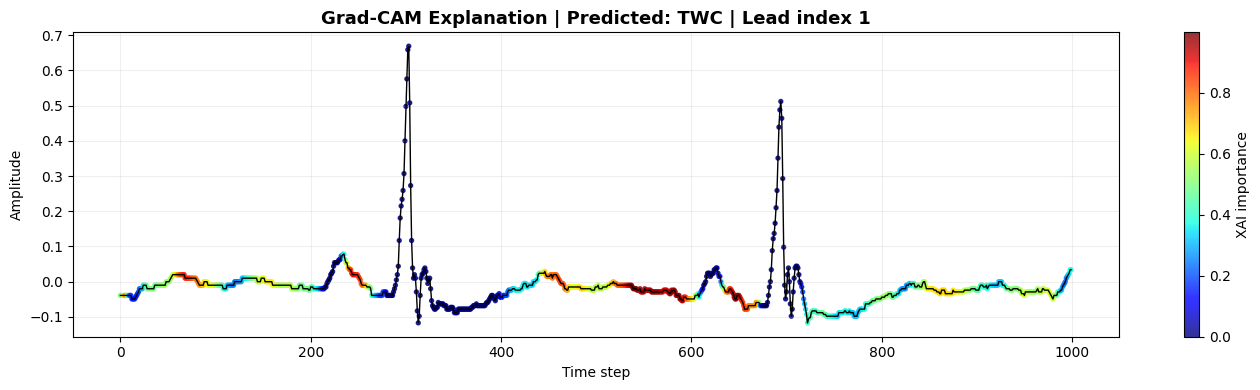

In [42]:
# Choose which signal to visualize
# x_input shape is already (1, leads, 1000)

target_layer = model.conv3
gradcam = GradCAM1D(model, target_layer)

cam, pred_cls, probs = gradcam.generate(x_input)

# pick signal to display
if x_input.shape[1] == 1:
    signal_to_plot = x_input[0, 0].detach().cpu().numpy()
    lead_name = f"Lead {inference_lead}" if inference_lead is not None else "Single Lead"
else:
    # For 12-lead mode, choose one lead to show; Lead II is index 1
    lead_to_show = 1
    signal_to_plot = x_input[0, lead_to_show].detach().cpu().numpy()
    lead_name = f"Lead index {lead_to_show}"

plot_ecg_with_heatmap(
    signal_to_plot,
    cam,
    title=f"Grad-CAM Explanation | Predicted: {CLASS_NAMES[pred_cls]} | {lead_name}"
)

gradcam.remove_hooks()

In [ ]:
# ── Export model + metadata for deployment ────────────────────────────
import json, torch

# Save the model
torch.save(model.state_dict(), '/content/drive/MyDrive/TESIS-V2/model.pt')

# Save metadata so the API knows class names and config without hardcoding
metadata = {
    "class_names": CLASS_NAMES,
    "n_leads":     N_LEADS,
    "n_classes":   OUTFEAT,
    "dropout_p":   DROPOUT_P,
    "lead_index":  LEAD_INDEX
}
with open('/content/drive/MyDrive/TESIS-V2/metadata.json', 'w') as f:
    json.dump(metadata, f)

print("✓ model.pt and metadata.json saved to /deploy/")

✓ model.pt and metadata.json saved to /deploy/
